### Check for GPU

In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device: ", device, torch.cuda.get_device_name(0) if device == 'cuda' else '')


Device:  cuda Tesla T4


### Fix the random seed

In [2]:
import random
import numpy as np

def set_seed(seed = 0):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)

set_seed(0)

## Loading the Fine tuned Vision Transformer Model
We will load the pretrained vision transformer 16, 224x224 that is already fine tuned on cifar-10. Cifar-10 is a dataset of images of size-32x32. Later on we will upscale the images in the dataset to match the models 224x224 input requirement.

In [3]:
from transformers import ViTForImageClassification, ViTImageProcessor
# https://huggingface.co/aaraki/vit-base-patch16-224-in21k-finetuned-cifar10
MODEL_ID = "aaraki/vit-base-patch16-224-in21k-finetuned-cifar10"

processor = ViTImageProcessor.from_pretrained(MODEL_ID)
model = ViTForImageClassification.from_pretrained(MODEL_ID).to(device).eval()


n_params = 0
for p in model.parameters():
  n_params += p.numel()

labels = model.config.id2label

print(f"Number of parameters: {n_params / 1000000} M")
print(f"Labels:", labels)


preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  343MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Number of parameters: 85.806346 M
Labels: {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}


## Load Cifar 10 test data

CIFAR-10 comes with images of size 32 x 32. But the ViT expects 224 x 224. So we need to upscale the images to match the model's requirement of 224 x 224. We use the same mean and standard deviation as the model was trained on to normalize the data. To keep the experiments running quickly we will use the same test set of 1000 images, using our seeded generator.

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

size = processor.size["height"]
resultant_size = (size, size)
resize_config = transforms.Resize(resultant_size)
image_mean = processor.image_mean
image_std = processor.image_std

tf = transforms.Compose([
    resize_config,
    transforms.ToTensor(),
    transforms.Normalize(image_mean, image_std)
])

test_set = datasets.CIFAR10("./data", train=False, download=True, transform=tf)
print("Test set classes: ", test_set.classes)

g = torch.Generator().manual_seed(0)
idx = torch.randperm(len(test_set), generator = g)[:1000].tolist()
loader = DataLoader(Subset(test_set, idx), batch_size=64, shuffle=False, num_workers=2)



model.safetensors: reconstructing file:   0%|          |  0.00B /  343MB            

model.safetensors: downloading bytes:           |  0.00B            



  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<10:07, 281kB/s]

  0%|          | 229k/170M [00:00<02:44, 1.03MB/s]

  0%|          | 557k/170M [00:00<01:30, 1.87MB/s]

  0%|          | 852k/170M [00:00<01:15, 2.24MB/s]

  1%|          | 1.11M/170M [00:00<01:13, 2.31MB/s]

  1%|          | 1.41M/170M [00:00<01:07, 2.51MB/s]

  1%|          | 1.74M/170M [00:00<01:01, 2.73MB/s]

  1%|          | 2.10M/170M [00:00<00:57, 2.92MB/s]

  1%|▏         | 2.46M/170M [00:00<00:53, 3.12MB/s]

  2%|▏         | 2.79M/170M [00:01<00:53, 3.12MB/s]

  2%|▏         | 3.24M/170M [00:01<00:47, 3.52MB/s]

  2%|▏         | 3.70M/170M [00:01<00:43, 3.81MB/s]

  2%|▏         | 4.23M/170M [00:01<00:39, 4.18MB/s]

  3%|▎         | 4.65M/170M [00:01<00:46, 3.55MB/s]

  3%|▎         | 5.05M/170M [00:01<00:58, 2.83MB/s]

  3%|▎         | 5.37M/170M [00:01<01:04, 2.55MB/s]

  3%|▎         | 5.67M/170M [00:02<01:10, 2.33MB/s]

  3%|▎         | 5.93M/170M [00:02<01:14, 2.21MB/s]

  4%

Test set classes:  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Evaluate BaseLine Accuracy
We are using `@torch.no_grad that means we are telling pytorch not to track the gradients. This saves memory and time, because it is only performing inference.
For each image we use argmax to get the class with the highest score and then count how many times it matches the correct label.

In [5]:
import time

@torch.no_grad()

def evaluate(model, loader):
  model.eval()
  correct = total = 0
  for x,y in loader:
    x, y = x.to(device), y.to(device)
    logits = model(pixel_values=x).logits
    correct += (logits.argmax(dim=-1) == y).sum().item()
    total += y.numel()

  return correct / total

t0 = time.time()
base_line_accuracy = evaluate(model, loader)
print(f"Baseline FP32 Accuracy: {base_line_accuracy*100:.2f} % {time.time() - t0:.1f}s")

Baseline FP32 Accuracy: 98.30 % 13.5s


## Where can faults happen

A Vision transformer is mostly linear layers with attention blocks (query, key, value, output) and feed forward MLP layers. In this code below, we calculate how many weights, sit in each block, i.e. the attention / mlp block.

In [6]:
import torch.nn as nn

linear_layers = {name: m for name, m in model.named_modules() if isinstance(m, nn.Linear)}
print("Number of Linear layers:", len(linear_layers))
for name in list(linear_layers)[:8]:
    print(" ", name, tuple(linear_layers[name].weight.shape))

def group(name):
    if "attention" in name: return "attention"
    if "mlp" in name: return "mlp"
    return "other"

counts = {}
for name, m in linear_layers.items():
    counts[group(name)] = counts.get(group(name), 0) + m.weight.numel()
total = sum(counts.values())
for k, v in counts.items():
    print(f"{k:10s} {v/1e6:6.1f} M weights  ({v/total*100:.1f}%)")

Number of Linear layers: 73
  vit.layers.0.attention.q_proj (768, 768)
  vit.layers.0.attention.k_proj (768, 768)
  vit.layers.0.attention.v_proj (768, 768)
  vit.layers.0.attention.o_proj (768, 768)
  vit.layers.0.mlp.fc1 (3072, 768)
  vit.layers.0.mlp.fc2 (768, 3072)
  vit.layers.1.attention.q_proj (768, 768)
  vit.layers.1.attention.k_proj (768, 768)
attention    28.3 M weights  (33.3%)
mlp          56.6 M weights  (66.7%)
other         0.0 M weights  (0.0%)


## Replacing the Linear Layer with a Quantized Layer
This code replaces a normal linear layer. It stores the weights as INT8 integers plus 1 scale factor.

In [7]:
import torch.nn.functional as F

class QuantLinear(nn.Module):
    def __init__(self, linear):
        super().__init__()
        w = linear.weight.data
        scale = w.abs().amax(dim=1) / 127            # one scale per row
        scale = scale.clamp(min=1e-12)               # avoid dividing by zero
        q = torch.round(w / scale[:, None]).clamp(-127, 127).to(torch.int8)
        self.register_buffer("w_int8", q)
        self.register_buffer("scale", scale.float())
        self.bias = linear.bias

    def forward(self, x):
        w = self.w_int8.float() * self.scale[:, None]   # integers back to decimals
        return F.linear(x, w, self.bias)

## Quantize the model
This part copies the original model, and keeps the original one, so that it can be used for comparison, then it swaps all the linear layers with QuantLinear layers in the copy.

In [8]:
import copy

def quantize_model(model):
    qmodel = copy.deepcopy(model)
    for module in list(qmodel.modules()):
        for child_name, child in list(module.named_children()):
            if isinstance(child, nn.Linear):
                setattr(module, child_name, QuantLinear(child))
    return qmodel

qmodel = quantize_model(model).eval()
print("Quantized layers:", sum(isinstance(m, QuantLinear) for m in qmodel.modules()))

Quantized layers: 73


### Analyze the result
This part evaluates the INT8 model.
It compares memory use.
Inspects one layer up close by examining what the stored integers look like and what the rounding error is.
The maximum error should not be more than half a scale step, because rounding is never off by more than half.


In [10]:
t0 = time.time()
int8_acc = evaluate(qmodel, loader)
print(f"INT8 accuracy: {int8_acc*100:.2f}%  (FP32 was {base_line_accuracy*100:.2f}%)  ({time.time()-t0:.1f}s)")

fp32_mb = sum(m.weight.numel() * 4 for m in linear_layers.values()) / 1e6
int8_mb = sum(m.w_int8.numel() + m.scale.numel() * 4
              for m in qmodel.modules() if isinstance(m, QuantLinear)) / 1e6
print(f"Linear weight memory: FP32 {fp32_mb:.1f} MB  ->  INT8 {int8_mb:.1f} MB")

name = "vit.layers.0.attention.q_proj"
orig = model.get_submodule(name).weight
q = qmodel.get_submodule(name)
deq = q.w_int8.float() * q.scale[:, None]
print("First 8 stored integers:", q.w_int8[0, :8].tolist())
print(f"Max rounding error: {(orig - deq).abs().max().item():.6f}")
print(f"Half a scale step:  {(q.scale / 2).max().item():.6f}")

INT8 accuracy: 98.30%  (FP32 was 98.30%)  (14.8s)
Linear weight memory: FP32 339.8 MB  ->  INT8 85.3 MB
First 8 stored integers: [4, 60, -33, -13, -66, 53, 24, -66]
Max rounding error: 0.007292
Half a scale step:  0.007320


## Flipping Bits
In this part, we declare functions for flipping bits of int8 and float32.
And then examine how flipping the bits of a number affects it.

In [11]:
def flip_int8(value, bit):
    t = torch.tensor([value], dtype=torch.int8)
    return (t.view(torch.uint8) ^ (1 << bit)).view(torch.int8).item()

def flip_float32(value, bit):
    t = torch.tensor([value], dtype=torch.float32)
    mask = torch.tensor(-(1 << 31) if bit == 31 else (1 << bit), dtype=torch.int32)
    return (t.view(torch.int32) ^ mask).view(torch.float32).item()

print("INT8 weight = 60  (binary", format(60, "08b") + ")")
for bit in [0, 3, 6, 7]:
    print(f"  flip bit {bit}:  60 -> {flip_int8(60, bit)}")

print("\nScale factor = 0.0146")
for bit in [0, 10, 22, 23, 29, 30, 31]:
    part = "mantissa" if bit < 23 else ("exponent" if bit < 31 else "sign")
    print(f"  flip bit {bit:2d} ({part:8s}):  0.0146 -> {flip_float32(0.0146, bit):.6g}")

INT8 weight = 60  (binary 00111100)
  flip bit 0:  60 -> 61
  flip bit 3:  60 -> 52
  flip bit 6:  60 -> 124
  flip bit 7:  60 -> -68

Scale factor = 0.0146
  flip bit  0 (mantissa):  0.0146 -> 0.0146
  flip bit 10 (mantissa):  0.0146 -> 0.014599
  flip bit 22 (mantissa):  0.0146 -> 0.0106938
  flip bit 23 (exponent):  0.0146 -> 0.0292
  flip bit 29 (exponent):  0.0146 -> 7.91468e-22
  flip bit 30 (exponent):  0.0146 -> 4.96812e+36
  flip bit 31 (sign    ):  0.0146 -> -0.0146


## Inject / Undo Faults
In this part we will inject faults and then undo them, because we want to test each fault in isolation and don't want them to pile up, because in that case the results would become meaningless

In [12]:
qlayers = {name: m for name, m in qmodel.named_modules() if isinstance(m, QuantLinear)}

def inject_fault(target, bit, group_name):
    names = [n for n in qlayers if group(n) == group_name]
    name = random.choice(names)
    layer = qlayers[name]
    if target == "weight":
        flat = layer.w_int8.view(-1)          # all weights in one long list
        i = random.randrange(flat.numel())
        old = flat[i].item()
        flat[i] = flip_int8(old, bit)
    else:
        flat = layer.scale
        i = random.randrange(flat.numel())
        old = flat[i].item()
        flat[i] = flip_float32(old, bit)
    return (flat, i, old, name)

def undo_fault(info):
    flat, i, old, _ = info
    flat[i] = old

### Testing a fault
Before we do a big experiment, lets test the setup with just 1 fault. We inject 1 scale factor fault bit 30 into an attention layer, measure accuracy, undo it and then measure again. The second number must be back to 98.30%. If it isn't then that means that the undo is not working properly.

In [13]:
set_seed(1)
info = inject_fault("scale", 30, "attention")
print("Injected into:", info[3], "| position:", info[1])
print(f"Accuracy with fault: {evaluate(qmodel, loader)*100:.2f}%")

undo_fault(info)
print(f"Accuracy after undo: {evaluate(qmodel, loader)*100:.2f}%")

Injected into: vit.layers.2.attention.q_proj | position: 582
Accuracy with fault: 10.00%
Accuracy after undo: 98.30%


## Experiment

This tests 4 combinations with 10 random faults each:

|Target|Bit|Group|
|------|---|-----|
|INT 8 Weight|7 (the worst INT8 Bit)|attention|
|INT 8 Weight|7|MLP|
|Scale Factor|30 (the worst float bit)|attention|
|Scale Factor|30|MLP|

`try/finally` ensures that `undo_fault` runs even if the evaluation runs into problems. At the end we use pandas to summarize average, best, worst accuracy for each combination.
In the end we do a final clean evaluation to ensure that model is back to normal.



In [14]:
import pandas as pd

configs = [("weight", 7, "attention"), ("weight", 7, "mlp"),
           ("scale", 30, "attention"), ("scale", 30, "mlp")]
N_TRIALS = 10
results = []
set_seed(42)

for target, bit, grp in configs:
    for trial in range(N_TRIALS):
        info = inject_fault(target, bit, grp)
        try:
            acc = evaluate(qmodel, loader)
        finally:
            undo_fault(info)
        results.append(dict(target=target, bit=bit, group=grp, layer=info[3], acc=acc))
    print(f"done: {target} bit {bit} {grp}")

df = pd.DataFrame(results)
summary = df.groupby(["target", "bit", "group"])["acc"].agg(["mean", "min", "max"]) * 100
print(summary.round(2))
print(f"\nClean accuracy after all trials: {evaluate(qmodel, loader)*100:.2f}%")

done: weight bit 7 attention
done: weight bit 7 mlp
done: scale bit 30 attention
done: scale bit 30 mlp
                       mean   min   max
target bit group                       
scale  30  attention  10.03  10.0  10.3
           mlp        10.00  10.0  10.0
weight 7   attention  98.30  98.3  98.3
           mlp        98.30  98.3  98.3

Clean accuracy after all trials: 98.30%


### Verifying why the model fails
So flipping the worst bit in model weights does insignficant damage, but if you flip the worst bit in the scale factors then the damage is catastrophic.
Now we will try to investigate why the accuracy for that is landing at 10%. My Guess is that it is because the model gets destroyed, and model keeps prediction the same class for every input and then since there are 10% of each class there, it predicts those correctly. Kind of like how a broken class is correct twice a day.

In [15]:
set_seed(3)
info = inject_fault("scale", 30, "mlp")
x, y = next(iter(loader))
with torch.no_grad():
    logits = qmodel(pixel_values=x.to(device)).logits
undo_fault(info)

print("Any NaN:", torch.isnan(logits).any().item(), "| Any inf:", torch.isinf(logits).any().item())
print("Predicted:", logits.argmax(-1)[:20].tolist())
print("True:     ", y[:20].tolist())

Any NaN: True | Any inf: False
Predicted: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
True:      [7, 5, 7, 8, 8, 8, 6, 1, 8, 8, 9, 8, 7, 0, 3, 1, 2, 4, 9, 7]


### Evaluations that also count NaNs
This is the same as evaluate, but it also counts how many images got NaN outputs. That lets us separate detectable failures (NaN) from silent ones (wrong answers without NaN).

In [16]:
@torch.no_grad()
def evaluate_detail(model, loader):
    model.eval()
    correct = total = nan_imgs = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(pixel_values=x).logits
        correct += (logits.argmax(-1) == y).sum().item()
        nan_imgs += torch.isnan(logits).any(dim=-1).sum().item()
        total += y.numel()
    return correct / total, nan_imgs / total

### Run the sweep

Now we will loop over all 32 bits, to see which bits are sensitive in the scaling factor.

Lets also save the results in a csv file so we don't lose them, in case collab disconnects.



In [17]:
sweep = []
set_seed(7)
t0 = time.time()
for bit in range(32):
    for trial in range(3):
        grp = "attention" if trial % 2 == 0 else "mlp"
        info = inject_fault("scale", bit, grp)
        try:
            acc, nan_frac = evaluate_detail(qmodel, loader)
        finally:
            undo_fault(info)
        sweep.append(dict(bit=bit, group=grp, acc=acc, nan=nan_frac))
    print(f"bit {bit:2d} done  ({time.time()-t0:.0f}s)")

sweep_df = pd.DataFrame(sweep)
sweep_df.to_csv("scale_bit_sweep.csv", index=False)

bit  0 done  (45s)
bit  1 done  (86s)
bit  2 done  (129s)
bit  3 done  (170s)
bit  4 done  (213s)
bit  5 done  (255s)
bit  6 done  (297s)
bit  7 done  (339s)
bit  8 done  (381s)
bit  9 done  (423s)
bit 10 done  (465s)
bit 11 done  (507s)
bit 12 done  (550s)
bit 13 done  (592s)
bit 14 done  (634s)
bit 15 done  (676s)
bit 16 done  (718s)
bit 17 done  (761s)
bit 18 done  (803s)
bit 19 done  (845s)
bit 20 done  (887s)
bit 21 done  (929s)
bit 22 done  (972s)
bit 23 done  (1014s)
bit 24 done  (1057s)
bit 25 done  (1099s)
bit 26 done  (1141s)
bit 27 done  (1184s)
bit 28 done  (1226s)
bit 29 done  (1268s)
bit 30 done  (1309s)
bit 31 done  (1351s)


### Plot the sweep
1 bar per bit position showing avg accuracy.

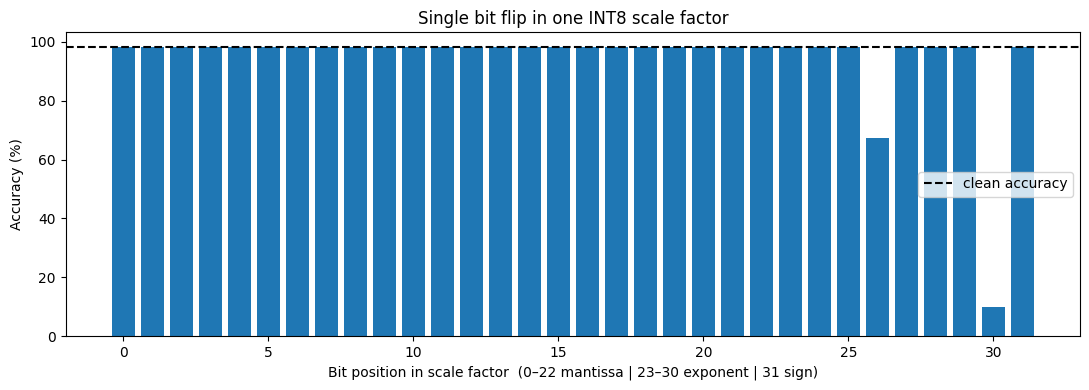

       acc    nan
bit              
0    98.30    0.0
1    98.30    0.0
2    98.30    0.0
3    98.30    0.0
4    98.30    0.0
5    98.30    0.0
6    98.30    0.0
7    98.30    0.0
8    98.30    0.0
9    98.30    0.0
10   98.30    0.0
11   98.30    0.0
12   98.30    0.0
13   98.30    0.0
14   98.30    0.0
15   98.30    0.0
16   98.30    0.0
17   98.30    0.0
18   98.30    0.0
19   98.30    0.0
20   98.30    0.0
21   98.30    0.0
22   98.30    0.0
23   98.30    0.0
24   98.30    0.0
25   98.27    0.0
26   67.27    0.0
27   98.27    0.0
28   98.23    0.0
29   98.30    0.0
30   10.00  100.0
31   98.30    0.0


In [19]:
import matplotlib.pyplot as plt

s = sweep_df.groupby("bit")[["acc", "nan"]].mean()
plt.figure(figsize=(11, 4))
plt.bar(s.index, s["acc"] * 100)
plt.axhline(base_line_accuracy * 100, ls="--", c="k", label="clean accuracy")
plt.xlabel("Bit position in scale factor  (0–22 mantissa | 23–30 exponent | 31 sign)")
plt.ylabel("Accuracy (%)")
plt.title("Single bit flip in one INT8 scale factor")
plt.legend(); plt.tight_layout(); plt.show()
print((s * 100).round(2).to_string())

### Investigating the bit 26


In [20]:
print(sweep_df[sweep_df.bit.isin([25, 26, 27, 28, 30])].to_string())

    bit      group    acc  nan
75   25  attention  0.983  0.0
76   25        mlp  0.982  0.0
77   25  attention  0.983  0.0
78   26  attention  0.114  0.0
79   26        mlp  0.971  0.0
80   26  attention  0.933  0.0
81   27  attention  0.982  0.0
82   27        mlp  0.983  0.0
83   27  attention  0.983  0.0
84   28  attention  0.982  0.0
85   28        mlp  0.982  0.0
86   28  attention  0.983  0.0
90   30  attention  0.100  1.0
91   30        mlp  0.100  1.0
92   30  attention  0.100  1.0


### Lessons from bit 26
Same bit can do nothing to almost destroy the model depending on which row it hits. bit 26 went 0.114 which is catastrophic to 0.97 which is small silent damage and 0.93 which is silent moderate damage.

## A lightweight Protection
We will record the largest scale factor in each layer. It's 73 numbers so won't eat up any significant memory.
Then at runtime if any scale is larger that than the largest scale factor, then we use **clamping** technique to cap it at that max value.
We only clap the top because scales that become too small are harmless, like we saw in case of bit29.

In [21]:
for m in qlayers.values():
    m.scale_max = m.scale.max().item()   # recorded once, while the model is clean
    m.protect = False

def protected_forward(self, x):
    scale = self.scale
    if self.protect:
        scale = scale.clamp(max=self.scale_max)   # cap anything too large
    w = self.w_int8.float() * scale[:, None]
    return F.linear(x, w, self.bias)

QuantLinear.forward = protected_forward

def set_protection(on):
    for m in qlayers.values():
        m.protect = on

### Check cost and weakness
Protection must not hurt healthy model, clean accuracy should stay at 98.3% and the time should barely change.
A possible weakness our protection has is within 1 layer rows can have different scales. If the smallest scale is more than 256x smaller than the largest, then a bit flip (x256) on that small row could stay under the cap and still slip through. Lets measure how big that gap is.


In [22]:
set_protection(True)
t0 = time.time()
print(f"Clean accuracy with protection: {evaluate(qmodel, loader)*100:.2f}%  ({time.time()-t0:.1f}s)")
set_protection(False)

ratios = [(m.scale.max() / m.scale.min()).item() for m in qlayers.values()]
print(f"Largest/smallest scale within a layer: median {np.median(ratios):.0f}x, worst {max(ratios):.0f}x")

Clean accuracy with protection: 98.30%  (12.7s)
Largest/smallest scale within a layer: median 4x, worst 32x


## Check if the protection idea works
For each trial, we will inject 1 fault, measure accuracy without protection then measure it with protection and then undo the fault.
To make it a fair comparison, we need to ensure that we use the same fault in both cases.
We will test bit 26 and 30 because they are the two that have significant or catastrophic accuracy loss when flipped.

In [23]:
prot = []
set_seed(11)
for bit in [26, 30]:
    for trial in range(10):
        grp = "attention" if trial % 2 == 0 else "mlp"
        info = inject_fault("scale", bit, grp)
        try:
            set_protection(False); acc_off, _ = evaluate_detail(qmodel, loader)
            set_protection(True);  acc_on, _  = evaluate_detail(qmodel, loader)
        finally:
            undo_fault(info); set_protection(False)
        prot.append(dict(bit=bit, group=grp, layer=info[3], unprotected=acc_off, protected=acc_on))
    print(f"bit {bit} done")

prot_df = pd.DataFrame(prot)
prot_df.to_csv("protection_results.csv", index=False)
print((prot_df.groupby("bit")[["unprotected", "protected"]].agg(["mean", "min"]) * 100).round(2))

bit 26 done
bit 30 done
    unprotected       protected      
           mean   min      mean   min
bit                                  
26        90.48  33.3     98.28  98.2
30        10.27  10.0     98.29  98.2


## Summary Plot

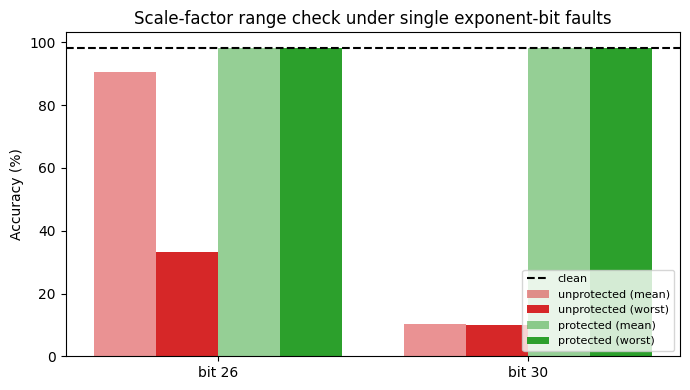

In [25]:
summary = prot_df.groupby("bit")[["unprotected", "protected"]].agg(["mean", "min"]) * 100
bits = summary.index.astype(str)
x = np.arange(len(bits)); w = 0.2

plt.figure(figsize=(7, 4))
plt.bar(x - 1.5*w, summary[("unprotected", "mean")], w, label="unprotected (mean)", color="tab:red", alpha=0.5)
plt.bar(x - 0.5*w, summary[("unprotected", "min")],  w, label="unprotected (worst)", color="tab:red")
plt.bar(x + 0.5*w, summary[("protected", "mean")],   w, label="protected (mean)", color="tab:green", alpha=0.5)
plt.bar(x + 1.5*w, summary[("protected", "min")],    w, label="protected (worst)", color="tab:green")
plt.axhline(base_line_accuracy * 100, ls="--", c="k", label="clean")
plt.xticks(x, ["bit " + b for b in bits])
plt.ylabel("Accuracy (%)")
plt.title("Scale-factor range check under single exponent-bit faults")
plt.legend(fontsize=8, loc="lower right"); plt.tight_layout()
plt.savefig("protection.png", dpi=150); plt.show()